# Advanced (optional) — featurizing a CIF the CGCNN way

**MS697 AI-driven Materials Development**
`Lecture 3 — Features (compositional and structural fingerprints) for materials`

A notebook that turns one CIF file into a crystal graph and then attaches features to that
graph until the representation carries the character of the crystal structure. Unlike a
matminer featurizer, which produces a single vector through formulas written by a person,
CGCNN treats the crystal as a graph whose nodes are atoms and whose edges are neighbour
relations, and attaches features to the nodes and to the edges. We go as far as building
that representation.

The example is one structure, anatase TiO₂. We find its neighbour relations and draw the
graph, attach element features to the nodes, bond features to the edges, and the global
features that come one per crystal. At each step we also check what else matminer can add.

The original paper is T. Xie & J. C. Grossman, *Phys. Rev. Lett.* **120**, 145301 (2018)
and the code is at <https://github.com/txie-93/cgcnn> (MIT License).

## Part 1: Setup

Two cells to run first: one installs the libraries, one downloads the course files.
We do not run the neural network, so `torch` is not needed. On Colab both cells have to
run again every time the runtime restarts.

In [ ]:
## A leading ! runs a terminal command instead of Python. -q keeps the install output quiet.
!pip install -q pymatgen networkx matminer

In [ ]:
## git clone downloads an entire repository from GitHub. Running it twice is harmless
## -- it just prints "destination path already exists".
!git clone https://github.com/kwongibaek/MS49900-AI4M.git

In [1]:
import sys, json, time, warnings
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

import matminer, pymatgen.core
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
np.set_printoptions(linewidth=140, suppress=True)

# 그림 글자 크기. 기본값(10pt)으로 그리면 슬라이드에 넣을 때 그림이 줄어들면서
# 3~5pt 로 찍혀 읽히지 않는다. 여기서 한 번 올려 두면 fontsize= 를 따로 주지 않은
# 축 눈금·축 이름·범례가 모두 따라오고, 볼드도 여기서 걸린다.
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold",
    "figure.titleweight": "bold",
})

print("python  :", sys.version.split()[0])
print("pymatgen:", pymatgen.core.__version__)
print("matminer:", matminer.__version__)
print("networkx:", nx.__version__)

python  : 3.11.15
pymatgen: 2026.5.18
matminer: 0.10.1
networkx: 3.6.1


### The crystal structure files

Every crystal structure used here was downloaded from the Materials Project and saved as a
CIF file in `Hand-on-session2/data/cif/` of the repository cloned above.

The cell below looks for that folder in a few places and uses the first one it finds, so the
same notebook works on Colab and on your own machine. If it raises `FileNotFoundError`, the
`git clone` cell above has not been run.

In [2]:
CIF_CANDIDATES = [
    Path("data/cif"),                                          # next to this notebook
    Path("../data/cif"),
    Path("MS49900-AI4M/Hand-on-session2/data/cif"),            # Colab, after the git clone above
    Path("/content/MS49900-AI4M/Hand-on-session2/data/cif"),
    Path("/content/drive/MyDrive/MS49900-AI4M/Hand-on-session2/data/cif"),
]
CIF_DIR = next((p for p in CIF_CANDIDATES if p.is_dir()), None)
if CIF_DIR is None:
    raise FileNotFoundError(
        "Could not find the data/cif folder. Upload the whole study_materials folder and "
        "run again, or add a path to CIF_CANDIDATES.")
DATA_DIR = CIF_DIR.parent

ATOM_INIT_CANDIDATES = [
    DATA_DIR / "cgcnn_atom_init.json",
    Path("../../codes/cgcnn/data/sample-regression/atom_init.json"),
    Path("../codes/cgcnn/data/sample-regression/atom_init.json"),
]
ATOM_INIT = next((p for p in ATOM_INIT_CANDIDATES if p.is_file()), None)
if ATOM_INIT is None:
    raise FileNotFoundError("Could not find atom_init.json.")

print("CIF folder    :", CIF_DIR.resolve())
print("atom_init.json:", ATOM_INIT.resolve())

CIF folder    : /home/ehddong11/ai4mat/Week3/feature/study_materials/data/cif
atom_init.json: /home/ehddong11/ai4mat/Week3/feature/study_materials/data/cgcnn_atom_init.json


## Part 2: Representing the crystal structure as a graph

CGCNN sees the crystal as a graph. The atoms are the nodes, and an edge runs from an atom to
each of its close neighbours inside a cutoff. The official implementation sorts the
neighbours inside an 8 Å cutoff by distance and keeps only the nearest twelve.

The neighbour search is written out as a function. When there are fewer than twelve
neighbours the official code fills the remaining slots with the distance `radius + 1`.

In [3]:
# Source: how CIFData.__getitem__ in cgcnn/data.py chooses neighbours (T. Xie, MIT License)
RADIUS, MAX_NBR = 8, 12


def neighbour_list(struct, max_num_nbr=MAX_NBR, radius=RADIUS):
    """Pick up to max_num_nbr neighbours per atom, in order of distance.

    Returns
    -------
    idx  : (N, max_num_nbr) index of the neighbouring atom
    dist : (N, max_num_nbr) distance to that neighbour (A)
    n_pad: number of atoms that had fewer than max_num_nbr neighbours and were padded
    """
    all_nbrs = [sorted(nbrs, key=lambda x: x[1])
                for nbrs in struct.get_all_neighbors(radius, include_index=True)]
    idx, dist, n_pad = [], [], 0
    for nbr in all_nbrs:
        if len(nbr) < max_num_nbr:
            n_pad += 1
            idx.append([x[2] for x in nbr] + [0] * (max_num_nbr - len(nbr)))
            dist.append([x[1] for x in nbr] + [radius + 1.] * (max_num_nbr - len(nbr)))
        else:
            idx.append([x[2] for x in nbr[:max_num_nbr]])
            dist.append([x[1] for x in nbr[:max_num_nbr]])
    return np.array(idx), np.array(dist), n_pad


anatase = Structure.from_file(CIF_DIR / "TiO2_anatase.cif")
nbr_idx, nbr_dist, n_pad = neighbour_list(anatase)
LABEL = [f"{i} {anatase[i].specie}" for i in range(len(anatase))]

print(f"anatase: {len(anatase)} atoms, cutoff {RADIUS} A, {MAX_NBR} neighbours")
print(f"neighbour index array {nbr_idx.shape}, distance array {nbr_dist.shape}, "
      f"{n_pad} atoms padded")
print()
for i in range(len(anatase)):
    print(f"  atom {i:2d} ({anatase[i].specie}) -> neighbour index {nbr_idx[i]}")
    print(f"               distance {np.round(nbr_dist[i], 3)}")

anatase: 12 atoms, cutoff 8 A, 12 neighbours
neighbour index array (12, 12), distance array (12, 12), 0 atoms padded

  atom  0 (Ti) -> neighbour index [ 4  6  6  4 11  5  3  3  1  1  0  0]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  1 (Ti) -> neighbour index [5 5 7 7 6 8 0 0 2 2 1 1]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  2 (Ti) -> neighbour index [ 8  8 10 10  9  7  1  3  1  3  2  2]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  3 (Ti) -> neighbour index [11  9 11  9 10  4  2  0  2  0  3  3]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  4 (O) -> neighbour index [ 0  0  3 11 11  6  6  6  6  5  5  9]
               distance [1.936 1.936 1.992 2.464 2.464 2.799 2.799 2.799 2.799 3.059 3.059 3.059]
  atom  5 (O) -> neighbour index [1 1 0 6 6 7

The shortest distance, 1.936 Å, is the Ti–O bond length.

There are twelve atoms in the cell and twelve neighbours per atom. Many of those neighbours
are periodic images outside the cell, and folding them back onto the original atoms makes
the same index appear several times in one row.

Let us record the symmetry; it comes up when we look at the node features.

In [4]:
sga = SpacegroupAnalyzer(anatase, symprec=0.1)
eq = sga.get_symmetry_dataset().equivalent_atoms

print(f"space group {sga.get_space_group_symbol()} ({sga.get_space_group_number()})")
print(f"{len(set(eq))} symmetrically distinct sites")
print("representative site index per atom:", eq)

space group I4_1/amd (141)
2 symmetrically distinct sites
representative site index per atom: [0 0 0 0 4 4 4 4 4 4 4 4]


The four Ti are equivalent to one another and so are the eight O. There are only two
distinct sites.

Let us draw the graph. On the left, every atom joined to its twelve neighbours in real
space; in the middle, the graph obtained by folding the periodic images back; on the right,
how many of the twelve neighbour slots point at each atom.

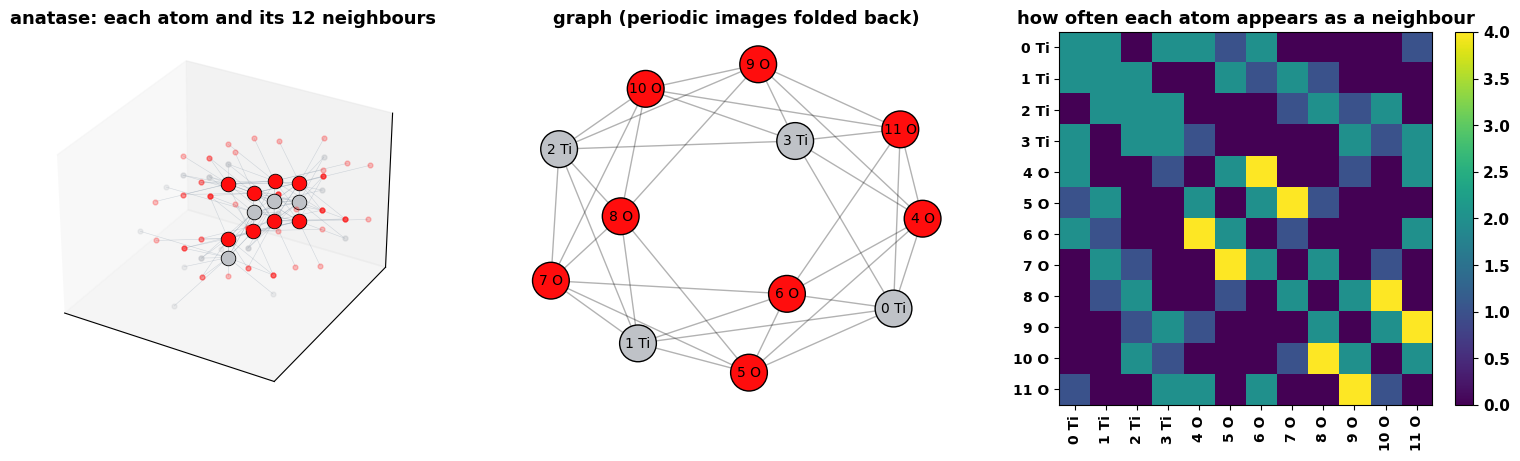

times an atom is its own neighbour, through a periodic image: 8


In [5]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

ELEM_COLOUR = {"Ti": "#BFC2C7", "O": "#FF0D0D", "Si": "#F0C8A0", "Zn": "#7D80B0",
               "S": "#FFFF30", "C": "#404040"}


def draw_crystal_graph(struct, name="", max_num_nbr=MAX_NBR, radius=RADIUS):
    """Draw the crystal graph in three panels: real space, abstract graph, adjacency counts."""
    nbrs = [sorted(nb, key=lambda x: x[1])[:max_num_nbr]
            for nb in struct.get_all_neighbors(radius, include_index=True)]
    idx = np.array([[nb.index for nb in row] for row in nbrs])
    n = len(struct)
    tick = [f"{i} {struct[i].specie}" for i in range(n)]
    fig = plt.figure(figsize=(15.5, 4.6))

    ax = fig.add_subplot(1, 3, 1, projection="3d")
    for i, site in enumerate(struct):
        for nb in nbrs[i]:
            p, q = site.coords, nb.coords
            ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                    lw=0.4, color="#8899AA", alpha=0.35)
            ax.scatter(*nb.coords, s=12, alpha=0.25, depthshade=False,
                       color=ELEM_COLOUR.get(str(nb.specie), "#888888"))
    for site in struct:
        ax.scatter(*site.coords, s=110, edgecolor="black", linewidth=0.6, depthshade=False,
                   color=ELEM_COLOUR.get(str(site.specie), "#888888"))
    ax.set_title(f"{name}: each atom and its {max_num_nbr} neighbours", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    ax = fig.add_subplot(1, 3, 2)
    G = nx.Graph()
    for i, site in enumerate(struct):
        G.add_node(i, el=str(site.specie))
    for i, row in enumerate(idx):
        for j in row:
            if int(j) != i:
                G.add_edge(i, int(j))
    pos = nx.spring_layout(G, seed=0)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=700, edgecolors="black",
                           node_color=[ELEM_COLOUR.get(G.nodes[k]["el"], "#888888")
                                       for k in G])
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10,
                            labels={k: f"{k} {G.nodes[k]['el']}" for k in G})
    ax.set_title("graph (periodic images folded back)", fontsize=13)
    ax.axis("off")

    ax = fig.add_subplot(1, 3, 3)
    C = np.zeros((n, n))
    for i, row in enumerate(idx):
        for j in row:
            C[i, int(j)] += 1
    im = ax.imshow(C, cmap="viridis")
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(n)); ax.set_xticklabels(tick, rotation=90, fontsize=10)
    ax.set_yticks(range(n)); ax.set_yticklabels(tick, fontsize=10)
    ax.set_title("how often each atom appears as a neighbour", fontsize=13)

    fig.tight_layout()
    return fig, C


_, C_anatase = draw_crystal_graph(anatase, "anatase")
plt.show()
print("times an atom is its own neighbour, through a periodic image:",
      int(np.trace(C_anatase)))

A count of 2 or more in the adjacency panel means the same atom entered the neighbour list
through several periodic images.

That is the skeleton of the graph. It does not yet carry which element an atom is, or how
long a bond is.

## Part 3: Attaching element features to the nodes

Every node gets a 92-dimensional vector. `atom_init.json` from the CGCNN repository maps an
atomic number to 92 zeros and ones. According to the paper (Table S1) it is a one-hot
binning of nine elemental properties, and it is a fixed table that is not trained.

In [6]:
raw = json.loads(ATOM_INIT.read_text())
M = np.array([raw[str(z)] for z in sorted(map(int, raw))])

print(f"{len(raw)} elements listed, whole table {M.shape}, set of values "
      f"{sorted(set(M.ravel().tolist()))}")
print(f"ones per element {M.sum(axis=1).min()} to {M.sum(axis=1).max()}, "
      f"columns that are never one: {int((M.sum(axis=0) == 0).sum())}")
print()
for el, z in [("Ti", 22), ("O", 8)]:
    print(f"{el} (Z={z}) positions that are one: "
          f"{np.flatnonzero(np.array(raw[str(z)])).tolist()}")
print("positions where Ti and O are both one:",
      int((np.array(raw['22']) * np.array(raw['8'])).sum()))

100 elements listed, whole table (100, 92), set of values [0, 1]
ones per element 6 to 9, columns that are never one: 2

Ti (Z=22) positions that are one: [4, 22, 28, 40, 49, 61, 72, 80, 85]
O (Z=8) positions that are one: [16, 20, 34, 37, 51, 64, 74, 79, 86]
positions where Ti and O are both one: 0


node feature matrix (12, 92)  (12 atoms x 92)


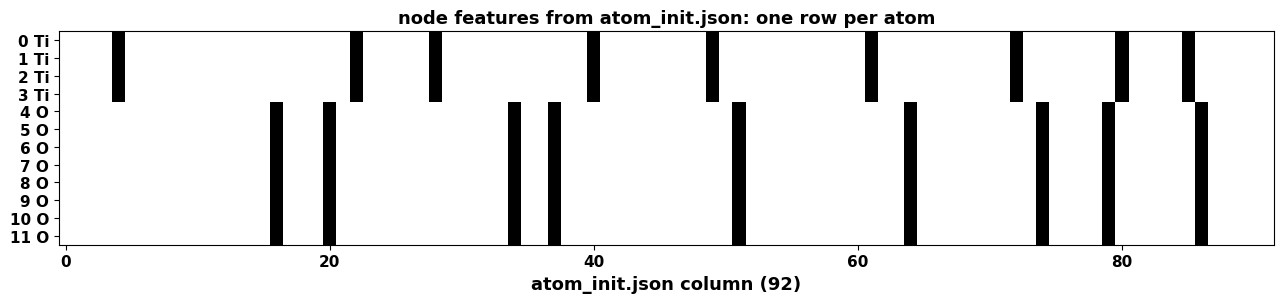

In [7]:
def node_features(struct, table):
    """Attach the 92-dimensional element feature to each atom. Decided by the element alone."""
    return np.vstack([table[str(site.specie.Z)] for site in struct]).astype(float)


atom_fea = node_features(anatase, raw)
print(f"node feature matrix {atom_fea.shape}  ({len(anatase)} atoms x 92)")

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.imshow(atom_fea, cmap="Greys", aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(anatase))); ax.set_yticklabels(LABEL, fontsize=11)
ax.set_xlabel("atom_init.json column (92)")
ax.set_title("node features from atom_init.json: one row per atom", fontsize=13)
plt.tight_layout()
plt.show()

The four Ti rows are identical and the eight O rows are identical. `atom_init.json` is a
table looked up by atomic number, so the same element gets the same row in whichever crystal
it sits. So far only composition information has entered the nodes.

### Adding node features from matminer

A matminer site featurizer returns a vector per atom, so it can be concatenated straight
onto the node features. Here is everything in `matminer.featurizers.site`, checked one by
one.

| featurizer | dim | what it looks at | needs |
|---|---|---|---|
| `SiteElementalProperty` (seko-prb-2017) | 22 | properties of the element on that site | — |
| `CoordinationNumber` | 1 | coordination number (`VoronoiNN` by default) | — |
| `CrystalNNFingerprint` (ops) | 61 | coordination-polyhedron order parameters | — |
| `OPSiteFingerprint` | 37 | the same thing by a different route | — |
| `ChemEnvSiteFingerprint` (simple) | 61 | ChemEnv coordination environments | — |
| `VoronoiFingerprint` | 30 | Voronoi polyhedron indicators | — |
| `IntersticeDistribution` | 12 | distribution of the gaps between atoms | — |
| `BondOrientationalParameter` | 10 | Steinhardt bond-orientational order parameters | — |
| `GaussianSymmFunc` | 8 | Behler–Parrinello symmetry functions | — |
| `AGNIFingerprints` | 32 | AGNI descriptor (includes directional components) | — |
| `AverageBondLength` | 1 | mean bond length | a neighbour-finder argument |
| `AverageBondAngle` | 1 | mean bond angle | a neighbour-finder argument |
| `LocalPropertyDifference` (ward-prb-2017) | 22 | property difference against the neighbours | — |
| `GeneralizedRadialDistributionFunction` (gaussian) | 10 | a per-site RDF | — |
| `AngularFourierSeries` (gaussian) | 400 | angular Fourier series | about 1.9 s per site |
| `EwaldSiteEnergy` | 1 | per-site Ewald energy | oxidation states |
| `ChemicalSRO` | 2 | deviation of the neighbour composition | `fit` |
| `SOAP` | — | series expansion of the atomic environment | `dscribe` installed |

Let us attach the nine that run with no preparation.

In [8]:
from matminer.featurizers.site import (AGNIFingerprints, AverageBondAngle, AverageBondLength,
                                       CoordinationNumber, CrystalNNFingerprint, GaussianSymmFunc,
                                       LocalPropertyDifference, SiteElementalProperty,
                                       VoronoiFingerprint)

NODE_EXTRA = {
    "SiteElementalProperty": SiteElementalProperty.from_preset("seko-prb-2017"),
    "CoordinationNumber": CoordinationNumber(),
    "CrystalNNFingerprint": CrystalNNFingerprint.from_preset("ops"),
    "VoronoiFingerprint": VoronoiFingerprint(),
    "GaussianSymmFunc": GaussianSymmFunc(),
    "AGNIFingerprints": AGNIFingerprints(),
    "AverageBondLength": AverageBondLength(CrystalNN()),
    "AverageBondAngle": AverageBondAngle(CrystalNN()),
    "LocalPropertyDifference": LocalPropertyDifference.from_preset("ward-prb-2017"),
}

ti = [i for i in range(len(anatase)) if str(anatase[i].specie) == "Ti"]
ox = [i for i in range(len(anatase)) if str(anatase[i].specie) == "O"]

blocks, rows = {}, []
for name, fz in NODE_EXTRA.items():
    t0 = time.time()
    X = np.array([fz.featurize(anatase, i) for i in range(len(anatase))], dtype=float)
    blocks[name] = X
    rows.append({"featurizer": name, "dim": X.shape[1],
                 "time (ms)": round((time.time() - t0) * 1000),
                 "Ti rows equal": bool(np.allclose(X[ti], X[ti][0], atol=1e-6)),
                 "O rows equal": bool(np.allclose(X[ox], X[ox][0], atol=1e-6))})
display(pd.DataFrame(rows).set_index("featurizer"))

X_extra = np.hstack([blocks[k] for k in NODE_EXTRA])
node_full = np.hstack([atom_fea, X_extra])
print(f"atom_init 92 + matminer {X_extra.shape[1]} = {node_full.shape[1]} node features")

,dim,time (ms),Ti rows equal,O rows equal
featurizer,,,,
SiteElementalProperty,22,0,True,True
CoordinationNumber,1,952,True,True
CrystalNNFingerprint,61,55,True,True
VoronoiFingerprint,30,34,True,True
GaussianSymmFunc,8,29,True,True
AGNIFingerprints,32,9,True,False
AverageBondLength,1,40,True,True
AverageBondAngle,1,40,True,True
LocalPropertyDifference,22,101,True,True


atom_init 92 + matminer 178 = 270 node features


The Ti rows agree with one another and so do the O rows, for the reason seen in Part 2: in
anatase the four Ti are equivalent and the eight O are equivalent.

Only `AGNIFingerprints` gives different values across the O rows. That descriptor keeps the
x, y and z components of the neighbour directions, so two sites that are symmetrically the
same but oriented differently get different values.

The coordination numbers show how much the answer depends on the neighbour definition.

In [9]:
cn = blocks["CoordinationNumber"].ravel()
cnnf = NODE_EXTRA["CrystalNNFingerprint"]
lab = cnnf.feature_labels()
Xc = blocks["CrystalNNFingerprint"]

print("CoordinationNumber (VoronoiNN):", cn)
print("AverageBondLength (CrystalNN):", np.round(blocks["AverageBondLength"].ravel(), 4))
print()
for i in [ti[0], ox[0]]:
    top = np.argsort(-Xc[i])[:4]
    print(f"site {i} ({anatase[i].specie}) largest CrystalNN order parameters:")
    for j in top:
        print(f"    {lab[j]:34s} {Xc[i, j]:.3f}")

CoordinationNumber (VoronoiNN): [ 6.  6.  6.  6. 17. 17. 17. 17. 17. 17. 17. 17.]
AverageBondLength (CrystalNN): [1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543]

site 0 (Ti) largest CrystalNN order parameters:
    wt CN_6                            0.965
    octahedral CN_6                    0.556
    pentagonal pyramidal CN_6          0.477
    hexagonal planar CN_6              0.212
site 4 (O) largest CrystalNN order parameters:
    wt CN_3                            0.965
    T-shaped CN_3                      0.551
    trigonal non-coplanar CN_3         0.369
    trigonal planar CN_3               0.219


`VoronoiNN` counts the coordination number of O as 17, because it counts every neighbour
that shares a Voronoi face. `CrystalNNFingerprint` gives the same site `wt CN_3` of 0.965
and reads it as three-coordinated. For Ti both routes say 6. The coordination number depends
on which neighbour definition is used.

`AverageBondLength` is 1.9543 Å on every site, because a Ti–O bond is the same bond whether
it is seen from the Ti or from the O.

Let us draw the extended node feature matrix. The 92 columns on the left of the line are
`atom_init.json`; the right side is what matminer added.

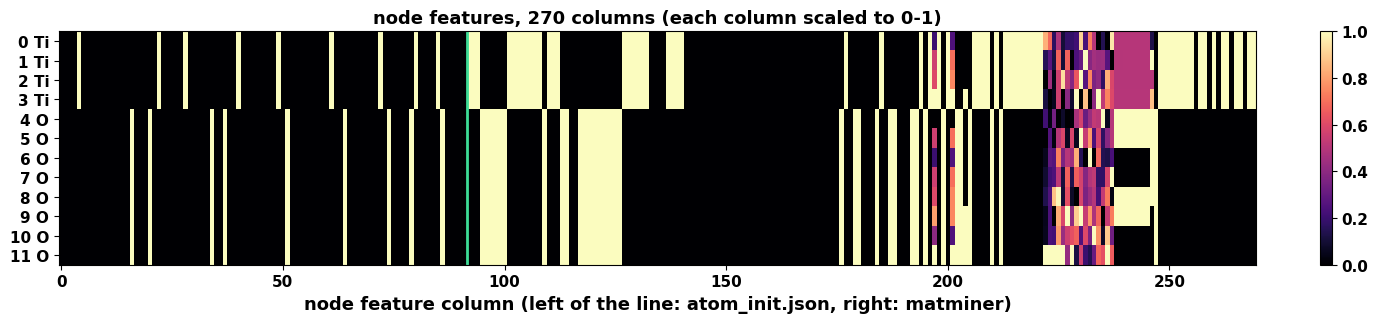

In [10]:
fig, ax = plt.subplots(figsize=(14, 3.4))
scaled = np.zeros_like(node_full)
rng = node_full.max(axis=0) - node_full.min(axis=0)
keep = rng > 0
scaled[:, keep] = (node_full[:, keep] - node_full[:, keep].min(axis=0)) / rng[keep]
im = ax.imshow(scaled, aspect="auto", cmap="magma", interpolation="nearest")
ax.axvline(92 - 0.5, color="#3DDC97", lw=2)
ax.set_yticks(range(len(anatase))); ax.set_yticklabels(LABEL, fontsize=11)
ax.set_xlabel("node feature column (left of the line: atom_init.json, right: matminer)")
ax.set_title(f"node features, {node_full.shape[1]} columns "
             "(each column scaled to 0-1)", fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

The `atom_init.json` side is only zeros and ones; the matminer side is continuous. In both
parts the Ti rows and the O rows have different patterns. The difference is that the left
side is decided by the element alone, and the right side by the arrangement of the
neighbours around that site.

## Part 4: Attaching bond features to the edges

Every edge carries two things: the distance to the neighbour, and which element that
neighbour is. The distances were already computed in Part 2.

In [11]:
nbr_species = np.array([[str(anatase[j].specie) for j in row] for row in nbr_idx])

print("edge distances (atoms x 12 neighbours)")
display(pd.DataFrame(np.round(nbr_dist, 3), index=LABEL,
                     columns=[f"nbr {k}" for k in range(MAX_NBR)]))
print("the element each edge points at")
display(pd.DataFrame(nbr_species, index=LABEL,
                     columns=[f"nbr {k}" for k in range(MAX_NBR)]))

edge distances (atoms x 12 neighbours)


,nbr 0,nbr 1,nbr 2,nbr 3,nbr 4,nbr 5,nbr 6,nbr 7,nbr 8,nbr 9,nbr 10,nbr 11
0 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
1 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
2 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
3 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
4 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
5 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
6 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
7 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
8 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
9 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059


the element each edge points at


,nbr 0,nbr 1,nbr 2,nbr 3,nbr 4,nbr 5,nbr 6,nbr 7,nbr 8,nbr 9,nbr 10,nbr 11
0 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
1 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
2 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
3 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
4 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
5 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
6 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
7 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
8 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
9 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O


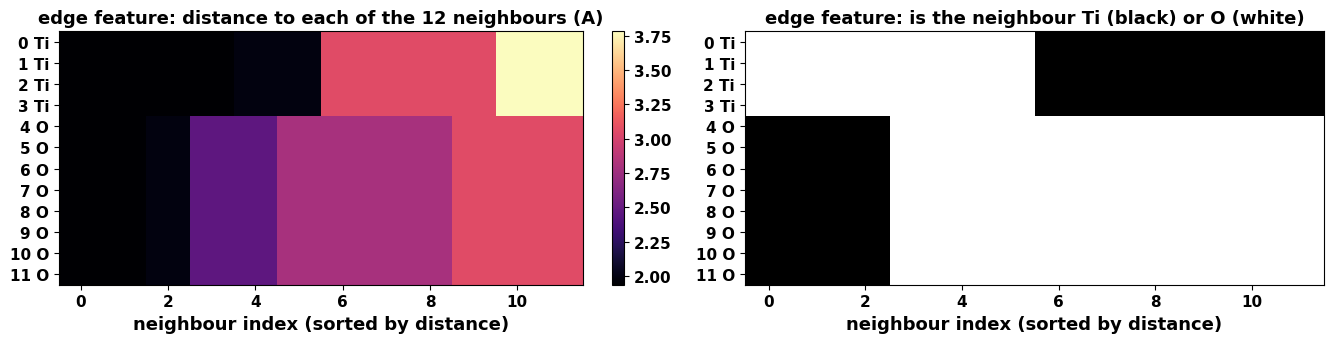

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.6))
im = axes[0].imshow(nbr_dist, aspect="auto", cmap="magma")
axes[0].set_title("edge feature: distance to each of the 12 neighbours (A)", fontsize=13)
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow((nbr_species == "Ti").astype(float), aspect="auto", cmap="Greys",
               interpolation="nearest")
axes[1].set_title("edge feature: is the neighbour Ti (black) or O (white)", fontsize=13)
for ax in axes:
    ax.set_yticks(range(len(anatase))); ax.set_yticklabels(LABEL, fontsize=11)
    ax.set_xlabel("neighbour index (sorted by distance)")
plt.tight_layout()
plt.show()

In the distance panel the left side is dark and it brightens towards the right, because the
neighbours are sorted by distance. The Ti rows and the O rows have different patterns.

When there are fewer than twelve neighbours the remaining slots are filled with
`radius + 1` = 9 Å. Let us make that happen by shrinking the cutoff to 3 Å.

In [13]:
idx_s, dist_s, n_pad_s = neighbour_list(anatase, radius=3.0)
print(f"cutoff 3.0 A: {n_pad_s} of {len(anatase)} atoms padded")
display(pd.DataFrame(np.round(dist_s, 3), index=LABEL,
                     columns=[f"nbr {k}" for k in range(MAX_NBR)]))

cutoff 3.0 A: 12 of 12 atoms padded


,nbr 0,nbr 1,nbr 2,nbr 3,nbr 4,nbr 5,nbr 6,nbr 7,nbr 8,nbr 9,nbr 10,nbr 11
0 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
1 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
2 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
3 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
4 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
5 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
6 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
7 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
8 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
9 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0


The slots that read 9 are the padded ones. Too small a cutoff empties the graph, which is
why 8 Å is the default.

The official implementation takes one more step here. The distance is not used as it is: it
is passed through a set of Gaussians with different centres and spread into a vector. This
is `GaussianDistance` in `cgcnn/data.py`, applied to the edge distances on the last line of
`CIFData.__getitem__`. The edge feature the network receives is that vector, not a single
distance.

41 filter centres: 0.0, 0.2, ... , 8.0 A (spacing 0.2 A, var 0.2)
distance array (12, 12) -> edge features (12, 12, 41),  144 numbers -> 5904


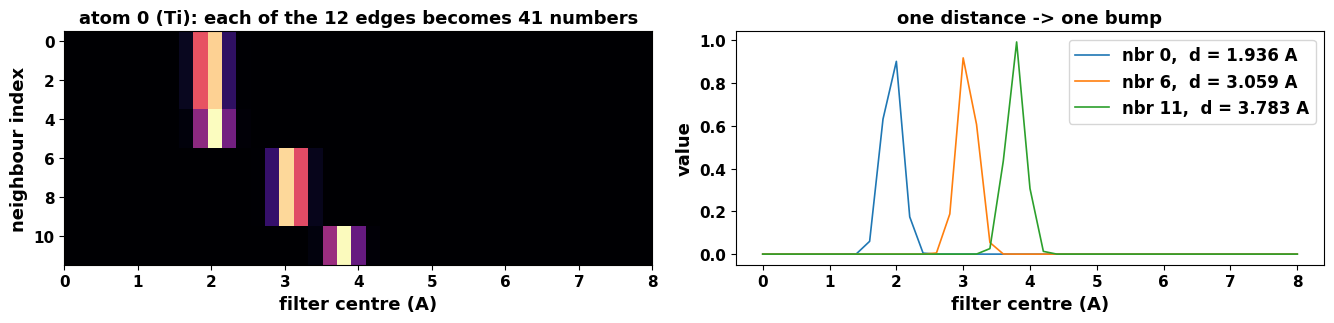

In [14]:
# Source: GaussianDistance in cgcnn/data.py (T. Xie, MIT License)
DMIN, DMAX, STEP = 0.0, RADIUS, 0.2


def expand_distance(dist, dmin=DMIN, dmax=DMAX, step=STEP, var=None):
    """Spread a distance over a set of Gaussians with different centres.

    The centres run from dmin to dmax with spacing step; var defaults to step.
    """
    centres = np.arange(dmin, dmax + step, step)
    var = step if var is None else var
    return np.exp(-(dist[..., np.newaxis] - centres) ** 2 / var ** 2)


centres = np.arange(DMIN, DMAX + STEP, STEP)
nbr_fea = expand_distance(nbr_dist)

print(f"{len(centres)} filter centres: {centres[0]:.1f}, {centres[1]:.1f}, ... , "
      f"{centres[-1]:.1f} A (spacing {STEP} A, var {STEP})")
print(f"distance array {nbr_dist.shape} -> edge features {nbr_fea.shape},  "
      f"{nbr_dist.size} numbers -> {nbr_fea.size}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.4))
axes[0].imshow(nbr_fea[0], aspect="auto", cmap="magma", interpolation="nearest",
               extent=[DMIN, DMAX, MAX_NBR - 0.5, -0.5])
axes[0].set_xlabel("filter centre (A)")
axes[0].set_ylabel("neighbour index")
axes[0].set_title(f"atom 0 ({anatase[0].specie}): each of the 12 edges "
                  f"becomes {len(centres)} numbers", fontsize=13)

for k in (0, 6, 11):
    axes[1].plot(centres, nbr_fea[0, k], lw=1.2,
                 label=f"nbr {k},  d = {nbr_dist[0, k]:.3f} A")
axes[1].set_xlabel("filter centre (A)")
axes[1].set_ylabel("value")
axes[1].set_title("one distance -> one bump", fontsize=13)
axes[1].legend(fontsize=12)
plt.tight_layout()
plt.show()

One distance has become 41 numbers. The neighbours are sorted by distance, so the bright
band steps down to the right in the left panel. In the right panel each bump stands at its
own distance. The centres are 0.2 Å apart, so a distance that falls between two centres has
a peak below 1: 0.90 at 1.936 Å.

`main.py` reads the last dimension of this array, 41, and uses it as the edge input width of
the model.

**Can matminer add edge features?** matminer has no featurizer that returns a value for one
edge. Everything it offers about bonds is a statistic over the whole crystal:
`BondFractions` gives the bond fraction per element pair, `BagofBonds` a collection of 1/r
over the bonds, and `PartialRadialDistributionFunction` a distance histogram per element
pair — and all three want `fit` called first and then return one vector per structure. What
goes on an edge, like the distance and the neighbouring element, has to be computed
directly.

## Part 5: Attaching global features

Node and edge features belong to one atom and one bond. Some values come one per crystal
instead: the lattice, the volume, the density, the space group — things one cannot ask a
single atom about.

The CGCNN network takes only nodes, edges and neighbour indices as its input
(`cgcnn/model.py`), and the representation of one crystal is the mean over its node
features. The original implementation has no slot for global features; from here on we are
widening the representation. We start with the ones we can write down ourselves.

In [15]:
def global_features(struct):
    """Values that come one per crystal. Their count does not depend on the atom count."""
    a, b, c = struct.lattice.abc
    al, be, ga = struct.lattice.angles
    sg = SpacegroupAnalyzer(struct, symprec=0.1)
    frac = struct.composition.fractional_composition
    return pd.Series({
        "a (A)": round(a, 4), "b (A)": round(b, 4), "c (A)": round(c, 4),
        "alpha": round(al, 2), "beta": round(be, 2), "gamma": round(ga, 2),
        "volume (A^3)": round(struct.volume, 3),
        "volume per atom": round(struct.volume / len(struct), 4),
        "density (g/cm^3)": round(float(struct.density), 4),
        "n atoms": len(struct),
        "spacegroup number": sg.get_space_group_number(),
        "frac Ti": round(frac.get_atomic_fraction("Ti"), 4),
        "frac O": round(frac.get_atomic_fraction("O"), 4),
    })


g_hand = global_features(anatase)
print(f"{len(g_hand)} hand-written global features")
display(g_hand.to_frame("anatase"))

13 hand-written global features


,anatase
a (A),3.7825
b (A),3.7825
c (A),9.6150
alpha,90.0000
beta,90.0000
gamma,90.0000
volume (A^3),137.5680
volume per atom,11.4640
density (g/cm^3),3.8561
n atoms,12.0000


A matminer structure featurizer returns one vector per structure, so it fits the global slot
directly. The list of structure features in the pre-class notebook is the list of candidates.
Let us attach the seven that run quickly.

| featurizer | dim | what it looks at |
|---|---|---|
| `DensityFeatures` | 3 | density, volume per atom, packing fraction |
| `MaximumPackingEfficiency` | 1 | maximum packing fraction |
| `GlobalSymmetryFeatures` | 3 | space-group number, crystal system, number of symmetry operations |
| `StructuralComplexity` | 2 | Shannon entropy of the structure |
| `ChemicalOrdering` | 3 | Warren-Cowley ordering parameters |
| `StructuralHeterogeneity` | 9 | spread of the Voronoi volumes and distances |
| `Dimensionality` | 1 | connectivity dimension |

Bigger ones are available too: `XRDPowderPattern` with 128 dimensions,
`RadialDistributionFunction` with 200, `OrbitalFieldMatrix` with 1024 and `JarvisCFID` with
1557. Here we keep to the small ones so that the values can be read on screen.

In [16]:
from matminer.featurizers.structure import (ChemicalOrdering, DensityFeatures, Dimensionality,
                                            GlobalSymmetryFeatures, MaximumPackingEfficiency,
                                            StructuralComplexity, StructuralHeterogeneity)

GLOBAL_EXTRA = {
    "DensityFeatures": DensityFeatures(),
    "MaximumPackingEfficiency": MaximumPackingEfficiency(),
    # crystal_system is a string and is_centrosymmetric is a bool, so take the numeric ones.
    "GlobalSymmetryFeatures": GlobalSymmetryFeatures(
        desired_features=["spacegroup_num", "crystal_system_int", "n_symmetry_ops"]),
    "StructuralComplexity": StructuralComplexity(),
    "ChemicalOrdering": ChemicalOrdering(),
    "StructuralHeterogeneity": StructuralHeterogeneity(),
    "Dimensionality": Dimensionality(),
}

parts, rows = [], []
for name, fz in GLOBAL_EXTRA.items():
    t0 = time.time()
    v = np.array(fz.featurize(anatase), dtype=float)
    parts.append(pd.Series(v, index=fz.feature_labels()))
    rows.append({"featurizer": name, "dim": len(v),
                 "time (ms)": round((time.time() - t0) * 1000)})
display(pd.DataFrame(rows).set_index("featurizer"))

g_matminer = pd.concat(parts)
print(f"{len(g_matminer)} global features added by matminer")
display(g_matminer.round(4).to_frame("anatase"))

g_full = pd.concat([g_hand, g_matminer])
print(f"hand-written {len(g_hand)} + matminer {len(g_matminer)} = {len(g_full)} global features")

,dim,time (ms)
featurizer,,
DensityFeatures,3,1
MaximumPackingEfficiency,1,610
GlobalSymmetryFeatures,3,3
StructuralComplexity,2,1
ChemicalOrdering,3,61
StructuralHeterogeneity,9,1
Dimensionality,1,46


22 global features added by matminer


,anatase
density,3.8561
vpa,11.4640
packing fraction,0.3868
max packing efficiency,0.3312
spacegroup_num,141.0000
crystal_system_int,4.0000
n_symmetry_ops,32.0000
structural complexity per atom,0.9183
structural complexity per cell,11.0196
mean ordering parameter shell 1,0.3134


hand-written 13 + matminer 22 = 35 global features


The density and the volume per atom from `DensityFeatures` are the same numbers we wrote by
hand. They are in there twice, so in practice the overlapping columns have to be filtered
out.

## Part 6: The finished representation

The three layers together are the representation of the one anatase CIF.

In [17]:
summary = pd.DataFrame([
    {"layer": "node (atom)", "shape": str(node_full.shape),
     "made of": "atom_init.json 92 + matminer site features 178",
     "what it holds": "which element sits there and how its neighbours are arranged"},
    {"layer": "edge (bond) distance", "shape": str(nbr_fea.shape),
     "made of": f"distance out to the 12th neighbour, spread over {nbr_fea.shape[-1]} Gaussians",
     "what it holds": "how far apart the atoms are"},
    {"layer": "edge (bond) neighbour", "shape": str(nbr_idx.shape),
     "made of": "index of the neighbouring atom (its element can be followed up)",
     "what it holds": "who is connected to whom"},
    {"layer": "global (crystal)", "shape": f"({len(g_full)},)",
     "made of": f"hand-written {len(g_hand)} + matminer structure features {len(g_matminer)}",
     "what it holds": "lattice, density, symmetry"},
])
display(summary.set_index("layer"))

print(f"one anatase CIF has become "
      f"{node_full.size + nbr_fea.size + nbr_idx.size + len(g_full)} numbers.")

,shape,made of,what it holds
layer,,,
node (atom),"(12, 270)",atom_init.json 92 + matminer site features 178,which element sits there and how its neighbour...
edge (bond) distance,"(12, 12, 41)","distance out to the 12th neighbour, spread ove...",how far apart the atoms are
edge (bond) neighbour,"(12, 12)",index of the neighbouring atom (its element ca...,who is connected to whom
global (crystal),"(35,)",hand-written 13 + matminer structure features 22,"lattice, density, symmetry"


one anatase CIF has become 9323 numbers.


The first dimension of the nodes and the edges is the atom count, 12. Put in a crystal with
a different atom count and it changes. Nothing is zero-padded to a common length the way
`SineCoulombMatrix` does; the sizes simply differ. Only the global features have a count that
does not depend on the crystal.

With `atom_init.json` alone the nodes carry only element information and all of the structure
sits on the edges. Adding matminer site featurizers makes the nodes carry the arrangement
around each site as well. The CGCNN network takes nodes and edges as its input and learns the
mixing of neighbour information itself, which is why the original implementation puts only
element information on the nodes.

## References and citations

- **CGCNN** — <https://github.com/txie-93/cgcnn> (T. Xie, MIT License). The way the
  neighbours are chosen and the `GaussianDistance` expansion are written out from
  `CIFData.__getitem__` in `cgcnn/data.py`, and
  the element feature table `atom_init.json` is the repository file itself
  (`data/cgcnn_atom_init.json`; the full licence is in `data/cgcnn_LICENSE.txt`).
- **matminer** — <https://hackingmaterials.lbl.gov/matminer/>, the site and structure
  featurizer lists.
- **matminer-notes** (`codes/matminer-notes.ipynb`) — the shape and the voice of this
  notebook.
- **Materials Project** (CC BY 4.0) — every crystal structure in `data/cif/`.

Original papers

- T. Xie & J. C. Grossman, *Phys. Rev. Lett.* **120**, 145301 (2018) — CGCNN
- L. Ward *et al.*, *Comput. Mater. Sci.* **152**, 60 (2018) — matminer
- S. P. Ong *et al.*, *Comput. Mater. Sci.* **68**, 314 (2013) — pymatgen

Sources of the site featurizers attached in Part 3, as reported by `citations()`.

- A. Seko *et al.*, *Phys. Rev. B* **95**, 144110 (2017) — `SiteElementalProperty`
- N. E. R. Zimmermann & A. Jain, *RSC Adv.* **10**, 6063 (2020) — the
  coordination-geometry order parameters behind `CrystalNNFingerprint`
- A. Okabe *et al.*, *Spatial Tessellations* (1992) — the Voronoi tessellation behind
  `CoordinationNumber` and `VoronoiFingerprint`
- H. L. Peng, M. Z. Li & W. H. Wang, *Phys. Rev. Lett.* **106**, 135503 (2011) —
  `VoronoiFingerprint`
- Q. Wang & A. Jain, *Nat. Commun.* **10**, 5537 (2019) — `VoronoiFingerprint`
- J. Behler, *J. Chem. Phys.* **134**, 074106 (2011) — `GaussianSymmFunc`
- A. Khorshidi & A. A. Peterson, *Comput. Phys. Commun.* **207**, 310 (2016) — the
  `GaussianSymmFunc` implementation
- V. Botu & R. Ramprasad, *Int. J. Quantum Chem.* **115**, 1074 (2015) — `AGNIFingerprints`
- M. de Jong *et al.*, *Sci. Rep.* **6**, 34256 (2016) — `AverageBondLength` and
  `AverageBondAngle`
- L. Ward *et al.*, *Phys. Rev. B* **96**, 024104 (2017) — `LocalPropertyDifference`, and
  `MaximumPackingEfficiency`, `ChemicalOrdering`, `StructuralHeterogeneity` in Part 5
- S. V. Krivovichev, *Mineral. Mag.* **77**, 275 (2013) — `StructuralComplexity`
- P. M. Larsen *et al.*, *Phys. Rev. Mater.* **3**, 034003 (2019) — `Dimensionality`